In [1]:
from os.path import exists
from copy import deepcopy
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pingouin as pg
from scipy.stats import rankdata, spearmanr, zscore
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA

In [2]:
data_dir = '/backup/data/social_actions/maternal_leave'

In [3]:
ls /backup/data/social_actions/maternal_leave

frame_arrangement_object_RDM.npy  search_RDMs_sq_zscore_p19_rh.npy
frame_arrangement_person_RDM.npy  search_RDMs_sq_zscore_p1_lh.npy
frame_arrangement_scene_RDM.npy   search_RDMs_sq_zscore_p1_rh.npy
gaze_rdm.npy                      search_RDMs_sq_zscore_p20_lh.npy
lh_mask_VT-v2.gii                 search_RDMs_sq_zscore_p20_rh.npy
nonverb_rdm.npy                   search_RDMs_sq_zscore_p21_lh.npy
object_rdm.npy                    search_RDMs_sq_zscore_p21_rh.npy
ppl_rdm.npy                       search_RDMs_sq_zscore_p22_lh.npy
pymoten_motion_energy_rdm.npy     search_RDMs_sq_zscore_p22_rh.npy
README.txt                        search_RDMs_sq_zscore_p23_lh.npy
rh_mask_VT-v2.gii                 search_RDMs_sq_zscore_p23_rh.npy
search_RDMs_sq_zscore_p10_lh.npy  search_RDMs_sq_zscore_p2_lh.npy
search_RDMs_sq_zscore_p10_rh.npy  search_RDMs_sq_zscore_p2_rh.npy
search_RDMs_sq_zscore_p11_lh.npy  search_RDMs_sq_zscore_p3_lh.npy
search_RDMs_sq_zscore_p11_rh.npy  search_RDMs_sq_zscore_p3_rh.npy
s

In [4]:
# Helper functions for GIfTI I/O
def read_gifti(f):
    return np.vstack([d.data[np.newaxis, :]
                      for d in nib.load(f).darrays])

def write_gifti(data, output_fn, template_fn):
    gii = nib.load(template_fn)
    for i in np.arange(gii.numDA):
        gii.remove_gifti_data_array(0)
    gda = nib.gifti.GiftiDataArray(data)
    gii.add_gifti_data_array(gda)
    # nib.gifti.write(gii, output_fn)
    gii.to_filename(output_fn)

In [5]:
# Define hemispheres, subjects, and VT masks
hemis = ['lh', 'rh']
subjects = np.arange(1, 24)

vt_masks = {'lh': read_gifti(data_dir + '/lh_mask_VT-v2.gii').astype(bool),
            'rh': read_gifti(data_dir + '/rh_mask_VT-v2.gii').astype(bool)}

In [6]:
# Load in searchlight maps and extract VT
if not exists('vt_searchlights.npy'):
    vt_maps = {'lh': {}, 'rh': {}}
    for hemi in hemis:
        for subject in subjects:
            rdm_map = np.load(data_dir + f'/search_RDMs_sq_zscore_p{subject}_{hemi}.npy', mmap_mode='r')
            vt_map = rdm_map[:, vt_masks[hemi][0]]
            vt_maps[hemi][subject] = vt_map
            print(f"Loaded VT searchlights for subject {subject} hemi {hemi}")

In [7]:
# Save VT searchlights and reload
if not exists('vt_searchlights.npy'):
    np.save('vt_searchlights.npy', vt_maps, allow_pickle=True)

vt_maps = np.load('vt_searchlights.npy', allow_pickle=True).item()
hemis = ['lh', 'rh']

In [8]:
# Average VT searchlight maps across subjects
vt_avg = {'lh': [], 'rh': []}
for hemi in hemis:
    vt_avg[hemi] = np.mean([v for v in vt_maps[hemi].values()], axis=0)   

In [9]:
# Run PCA to reduce vertices and find top RDM PCs
vt_pca, vt_vaf, vt_loadings, pca_objs = {}, {}, {}, {}
for hemi in hemis:
    pca = PCA()
    vt_pca[hemi] = pca.fit_transform(zscore(vt_avg[hemi], axis=0))
    vt_vaf[hemi] = pca.explained_variance_ratio_
    vt_loadings[hemi] = pca.components_ * np.sqrt(pca.explained_variance_)
    pca_objs[hemi] = deepcopy(pca)

for hemi in hemis:
    print(f"PC 1 explained {vt_vaf[hemi][0]:.3f} variance in {hemi} VT RDMs")

vaf_threshs = [.5, .75, .9, .95]
n_pcs = {}
for vaf_thresh in vaf_threshs:
    for hemi in hemis:
        n_pcs[hemi] = np.sum(np.cumsum(vt_vaf[hemi]) < vaf_thresh) + 1
        print(f"{n_pcs[hemi]} PCs required to explain {vaf_thresh:.2f} variance in {hemi} VT RDMs")

PC 1 explained 0.603 variance in lh VT RDMs
PC 1 explained 0.645 variance in rh VT RDMs
1 PCs required to explain 0.50 variance in lh VT RDMs
1 PCs required to explain 0.50 variance in rh VT RDMs
3 PCs required to explain 0.75 variance in lh VT RDMs
3 PCs required to explain 0.75 variance in rh VT RDMs
9 PCs required to explain 0.90 variance in lh VT RDMs
8 PCs required to explain 0.90 variance in rh VT RDMs
16 PCs required to explain 0.95 variance in lh VT RDMs
15 PCs required to explain 0.95 variance in rh VT RDMs


In [10]:
# # Bootstrap subjects for PCA CIs
# # Bootstrapping subjects behaves badly at higher PCs
# # likely due to PCA overfitting to a particular sample mean

# vt_maps = np.load('vt_searchlights.npy', allow_pickle=True).item()
# vt_maps['lh'] = np.stack(list(vt_maps['lh'].values()))
# vt_maps['rh'] = np.stack(list(vt_maps['rh'].values()))

# pca_objs = {}
# for hemi in hemis:
#     pca = PCA(n_components=5)
#     pca.fit(zscore(vt_avg[hemi], axis=0))
#     pca_objs[hemi] = deepcopy(pca)

# n_subjs = 23
# n_boots = 1000
# vt_pca_boot = {}
# for hemi in hemis:
#     vt_pca_boot[hemi] = []
#     for b in np.arange(n_boots):
#         boot_ids = np.random.choice(
#             np.arange(n_subjs), size=n_subjs, replace=True)
#         vt_avg_boot = np.mean(vt_maps[hemi][boot_ids], axis=0)
#         vt_pca_boot[hemi].append(
#             pca_objs[hemi].transform(zscore(vt_avg_boot, axis=0)))
#         if b % 100 == 0:
#             print(f"Finished PCA bootstrap {b}")

# vt_pca_boot['lh'] = np.stack(vt_pca_boot['lh'])
# vt_pca_boot['rh'] = np.stack(vt_pca_boot['rh'])
# np.save(f'vt_pca_bootstrap.npy', vt_pca_boot)

In [11]:
# Load in model RDMs and visualization utilities
reorder = [10, 11, 12, 13, 14, 65, 66, 67, 68, 69, 75, 76, 77, 78, 79,
           5, 6, 7, 8, 9, 40, 41, 42, 44, 45, 31, 32, 33, 34, 35,
           55, 56, 57, 58, 59, 25, 26, 27, 28, 29, 80, 81, 82, 83, 84,
           43, 46, 47, 48, 49, 30, 36, 37, 38, 39, 50, 51, 52, 53, 54,
           20, 21, 22, 23, 24, 85, 86, 87, 88, 89, 15, 16, 17, 18, 19,
           60, 61, 62, 63, 64, 0, 1, 2, 3, 4, 70, 71, 72, 73, 74]

sparse_ordered_labels = np.load(data_dir + '/sparse_ordered_labels.npy').astype(str)
sparse_ordered_labels[sparse_ordered_labels == 'cosmetics and grooming'] = 'grooming'
sparse_ordered_labels[sparse_ordered_labels == 'arts and crafts'] = 'arts/crafts'
sparse_ordered_labels[sparse_ordered_labels == 'musical performance'] = 'music'

model_names = {'motion': 'pymoten_motion_energy_rdm',
               'gaze': 'gaze_rdm',
               'nonverbs': 'nonverb_rdm',
               'verbs': 'verb_rdm',
               'scene': 'frame_arrangement_scene_RDM', 
               'person': 'frame_arrangement_person_RDM',
               'object': 'frame_arrangement_object_RDM', 
               'sociality': 'social_rdm',
               'transitivity': 'object_rdm'}

model_rdms = {}
for model_name in model_names:
    model_rdms[model_name] = np.load(data_dir + f'/{model_names[model_name]}.npy')

In [12]:
# RDM plotting function
def plot_rdm(rdm_vec, reorder=None, labels=None, save_f=None):
    plt.rcParams['svg.fonttype'] = 'none'
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        squareform(rankdata(rdm_vec) / len(rdm_vec) * 100)[reorder][:, reorder],
        vmin=0, vmax=100, square=True, cmap='RdYlBu_r', xticklabels=labels, 
        yticklabels=labels)
    ax.xaxis.tick_top()
    ax.tick_params(axis='both', length=0)
    for xt in ax.get_xticklabels():
        xt.set_fontsize(10.5)
    for yt in ax.get_yticklabels():
        yt.set_fontsize(10.5)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10.5)
    plt.xticks(rotation=45, ha='left')
    plt.yticks(va='top')
    plt.tight_layout()
    if save_f:
        plt.savefig(save_f, dpi=300, transparent=True,
                    bbox_inches='tight');
    plt.show()

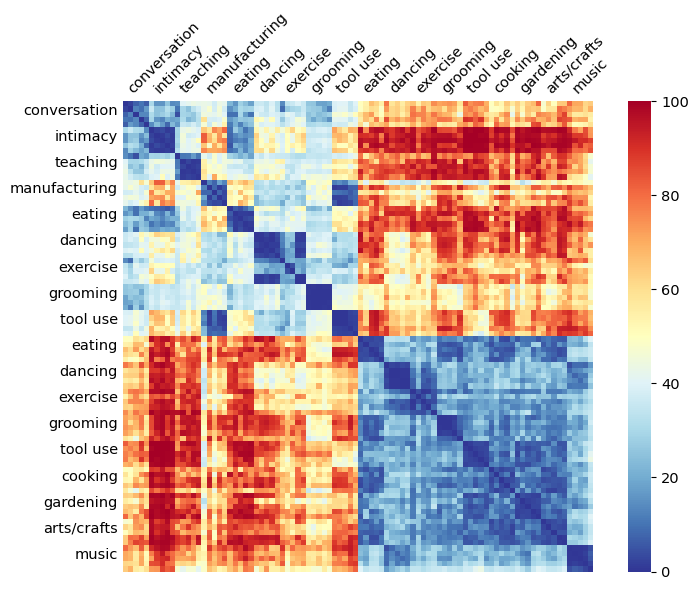

In [13]:
# Plot an example model RDM
plot_rdm(model_rdms['sociality'], reorder=reorder, labels=sparse_ordered_labels)

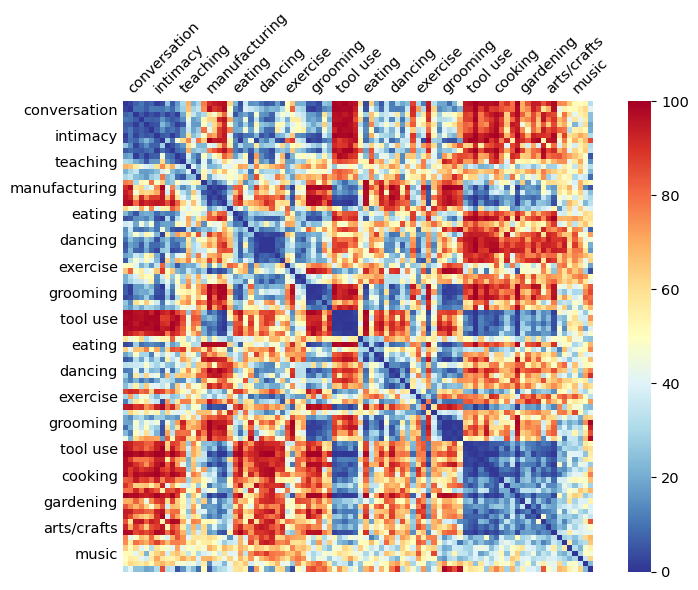

In [14]:
# Plot an example PC RDM
pc_id = 0
plot_rdm(vt_pca['lh'][:, pc_id], reorder=reorder, labels=sparse_ordered_labels)

In [15]:
# Compute correlations between PC RDMs and models
pc_corr = {'Spearman r': [], 'model': [], 'PC': [], 'hemisphere': []}
for hemi in hemis:
    for pc_id in np.arange(20):
        for model_name in model_names:
            # Absolute r because PCs have arbitrary polarity
            abs_r = np.abs(spearmanr(vt_pca[hemi][:, pc_id], model_rdms[model_name])[0])
            pc_corr['Spearman r'].append(abs_r)
            pc_corr['model'].append(model_name)
            pc_corr['PC'].append(pc_id + 1)
            pc_corr['hemisphere'].append(hemi)

pc_corr = pd.DataFrame(pc_corr)

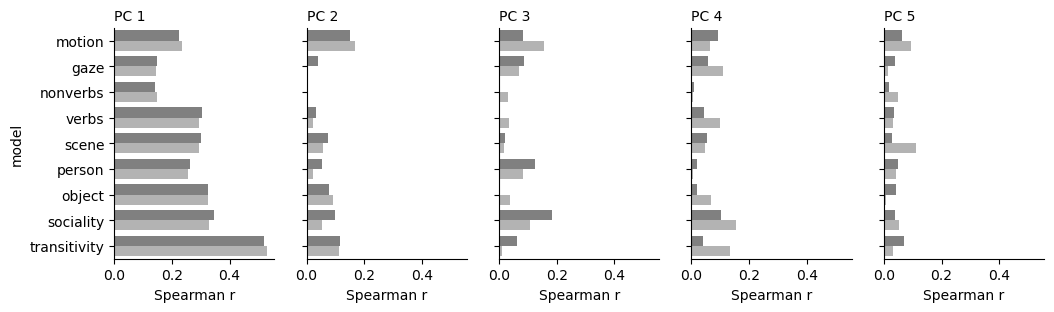

In [16]:
# Visualize correlations between PC RDMs and models
fig, axs = plt.subplots(1, 5, figsize=(12, 3), sharex=True, sharey=True)
for ax, pc_id in zip(axs, np.arange(1, 6)): 
    sns.barplot(x='Spearman r', y='model', hue='hemisphere',
                data=pc_corr.loc[pc_corr['PC'] == pc_id],
                palette=['.5', '.7'], ax=ax, legend=False)
    ax.annotate(f'PC {pc_id}', xy=(0, 1.02), xycoords='axes fraction',
                ha='left', va='bottom')
    sns.despine()

In [17]:
# # Skipping code to visualize subject-level bootstrap
# pc_boot = {'upper': [], 'lower': [], 'model': [], 'PC': [], 'hemisphere': []}
# for hemi in hemis:
#     for pc_id in np.arange(5):
#         for model_name in model_names:
#             # Absolute r because PCs have arbitrary polarity
#             abs_r_boots = []
#             for b in np.arange(n_boots):
#                 abs_r_boots.append(
#                     pearsonr(vt_pca_boot[hemi][b, :, pc_id],
#                              model_rdms[model_name])[0])
#             pc_boot['upper'].append(np.percentile(abs_r_boots, 97.5))
#             pc_boot['lower'].append(np.percentile(abs_r_boots, 2.5))
#             pc_boot['model'].append(model_name)
#             pc_boot['PC'].append(pc_id + 1)
#             pc_boot['hemisphere'].append(hemi)
#         print(f"Finished bootstrap correlations for PC {pc_id} {hemi}")

# pc_boot = pd.DataFrame(pc_boot)

In [18]:
# # Bootstrap row/column stimuli of RDM
# model_rdms_sq = {m: squareform(r) for m, r in model_rdms.items()}

# pc_boot = {'upper': [], 'lower': [], 'model': [], 'PC': [], 'hemisphere': []}
# n_conds = 90
# n_boots = 1000
# for hemi in hemis:
#     for pc_id in np.arange(5):
#         vt_sq = squareform(vt_pca[hemi][:, pc_id])
#         for model_name in model_names:
#             # Absolute r because PCs have arbitrary polarity
#             abs_r_boots = []
#             for b in np.arange(n_boots):
#                 boot_ids = np.sort(np.random.choice(
#                     np.arange(n_conds), n_conds, replace=True))
#                 vt_boot = squareform(vt_sq[boot_ids][:, boot_ids],
#                                      checks=False)
#                 model_boot = squareform(
#                     model_rdms_sq[model_name][
#                         boot_ids][:, boot_ids],
#                     checks=False)
#                 abs_r_boots.append(
#                     np.abs(spearmanr(vt_boot, model_boot)[0]))
#             pc_boot['upper'].append(np.percentile(abs_r_boots, 97.5))
#             pc_boot['lower'].append(np.percentile(abs_r_boots, 2.5))
#             pc_boot['model'].append(model_name)
#             pc_boot['PC'].append(pc_id + 1)
#             pc_boot['hemisphere'].append(hemi)
#         print(f"Finished bootstrap correlations for PC {pc_id} {hemi}")

# pc_boot = pd.DataFrame(pc_boot)

In [19]:
# # Visualize correlations between PC RDMs and models
# fig, axs = plt.subplots(1, 5, figsize=(12, 3), sharex=True, sharey=True)
# for ax, pc_id in zip(axs, np.arange(1, 6)): 
#     sns.barplot(x='Spearman r', y='model', hue='hemisphere',
#                 data=pc_corr.loc[pc_corr['PC'] == pc_id],
#                 palette=['.5', '.7'], ax=ax, legend=False)
#     ax.annotate(f'PC {pc_id}', xy=(0, 1.02), xycoords='axes fraction',
#                 ha='left', va='bottom')

#     cis = np.stack(((pc_corr['Spearman r'][pc_corr['PC'] == pc_id].values) - 
#                      pc_boot['lower'][pc_boot['PC'] == pc_id].values,
#                     (pc_boot['upper'][pc_boot['PC'] == pc_id].values -
#                      pc_corr['Spearman r'][pc_corr['PC'] == pc_id].values)))
#     cis[cis < 0] = 0
#     ci_y = [p.get_y() + 0.5 * p.get_height() for p in ax.patches]
#     ci_x = [p.get_width() for p in ax.patches]
#     ax.errorbar(x=ci_x, y=ci_y, xerr=cis, fmt='none', c='k', lw=.5)
#     sns.despine()

In [20]:
# Compile semi-partial correlations with model RDMs
pc_semis = {'semipartial Spearman r': [], 'model': [], 'PC': [], 'hemisphere': []}
for pc_id in np.arange(20):
    for hemi in hemis:
        for model_name in model_names:

            pc_df = pd.DataFrame(
                {'neural': vt_pca[hemi][:, pc_id],
                 **model_rdms})
            r = pg.partial_corr(
                data=pc_df, x='neural', y=model_name,
                x_covar=[m for m in model_rdms.keys()
                         if m is not model_name],
                method='spearman').r.abs().values[0]
            
            # Absolute r because PCs have arbitrary polarity
            pc_semis['semipartial Spearman r'].append(r)
            pc_semis['model'].append(model_name)
            pc_semis['PC'].append(pc_id + 1)
            pc_semis['hemisphere'].append(hemi)

pc_semis = pd.DataFrame(pc_semis)

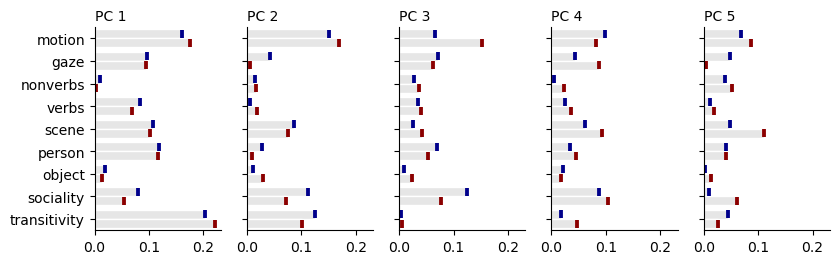

In [21]:
# Visualize correlations between PC RDMs and models
plt.rcParams['svg.fonttype'] = 'none'
fig, axs = plt.subplots(1, 5, figsize=(8.5, 2.75), sharex=True, sharey=True)
for ax, pc_id in zip(axs, np.arange(1, 6)): 
    sns.barplot(x='semipartial Spearman r', y='model', hue='hemisphere',
                data=pc_semis.loc[pc_semis['PC'] == pc_id],
                palette=['.9', '.9'], ax=ax, legend=False, edgecolor='w')
    sns.pointplot(x='semipartial Spearman r', y='model', hue='hemisphere',
                  data=pc_semis.loc[pc_semis['PC'] == pc_id],
                  palette=['darkblue', 'darkred'], ax=ax, legend=False,
                  linestyle='none', markersize=5.05, dodge=.4,
                  markers='|', markeredgewidth=2.75)
    ax.set(ylabel=None, xlabel=None)
    ax.annotate(f'PC {pc_id}', xy=(0, 1.02), xycoords='axes fraction',
                ha='left', va='bottom')
    sns.despine()
    plt.tight_layout()
    plt.savefig('vt_pca_k-5_bars.svg', dpi=300,
                transparent=True, bbox_inches='tight');

In [ ]:
plt.rcParams['svg.fonttype'] = 'none'
fig, axs = plt.subplots(1, 4, figsize=(6.5, 3), sharex=True, sharey=True)
for ax, cluster_id in zip(axs, [2, 4, 1, 3]): 
    sns.barplot(x='semipartial Spearman r', y='model', hue='hemisphere',
                data=cluster_semis.loc[cluster_semis['cluster'] == cluster_id],
                palette=['.9', '.9'], ax=ax, legend=False, edgecolor='w')
    sns.pointplot(x='semipartial Spearman r', y='model', hue='hemisphere',
                  data=cluster_semis.loc[cluster_semis['cluster'] == cluster_id],
                  palette=['darkblue', 'darkred'], ax=ax, legend=False,
                  linestyle='none', markersize=6, dodge=.4,
                  markers='|', markeredgewidth=1.5)
    ax.set(xlim=(-.038, .275), ylabel=None, xlabel=None)
    ax.annotate(f'cluster {cluster_id}', xy=(0, 1.02), xycoords='axes fraction',
                ha='left', va='bottom')
    cis = np.stack((
        (cluster_semis['semipartial Spearman r'][cluster_semis['cluster'] == cluster_id].values) - 
         cluster_boot['lower'][cluster_boot['cluster'] == cluster_id].values,
        (cluster_boot['upper'][cluster_boot['cluster'] == cluster_id].values -
         cluster_semis['semipartial Spearman r'][cluster_semis['cluster'] == cluster_id].values)))
    ci_y = [p.get_y() + 0.5 * p.get_height() for p in ax.patches]
    ci_x = [p.get_width() for p in ax.patches]
    cs = ['darkblue'] * 9 + ['darkred'] * 9
    for i in np.arange(len(ci_xs)):
        ax.errorbar(x=ci_x[i], y=ci_y[i], xerr=cis[:, i, np.newaxis],
                    fmt='none', c=cs[i], lw=1.5)
    sns.despine()
    plt.tight_layout()
    plt.savefig('vt_kmeans_k-4_bars.svg', dpi=300,
                transparent=True, bbox_inches='tight');

In [23]:
# # Compile semi-partial correlations with model RDMs
# model_rdms_sq = {m: squareform(r) for m, r in model_rdms.items()}

# if not exists('pc_semipartial_boot.csv'):
#     pc_boot = {'upper': [], 'lower': [], 'model': [], 'PC': [], 'hemisphere': []}
#     for pc_id in np.arange(5):
#         for hemi in hemis:
#             for model_name in model_names:
#                 vt_sq = squareform(vt_pca[hemi][:, pc_id])
#                 abs_r_boots = []
#                 for b in np.arange(n_boots):
#                     boot_ids = np.sort(np.random.choice(
#                         np.arange(n_conds), n_conds, replace=True))
#                     vt_boot = squareform(vt_sq[boot_ids][:, boot_ids],
#                                          checks=False)
#                     model_boots = {m: squareform(
#                         r[boot_ids][:, boot_ids], checks=False)
#                         for m, r in model_rdms_sq.items()}
                
#                     pc_df = pd.DataFrame(
#                         {'neural': vt_boot,
#                          **model_boots})
#                     abs_r_boots.append(pg.partial_corr(
#                         data=pc_df, x='neural', y=model_name,
#                         x_covar=[m for m in model_boots.keys()
#                                  if m is not model_name],
#                         method='spearman').r.abs().values[0])
    
#                 # Absolute r because PCs have arbitrary polarity
#                 pc_boot['upper'].append(np.percentile(abs_r_boots, 97.5))
#                 pc_boot['lower'].append(np.percentile(abs_r_boots, 2.5))
#                 pc_boot['model'].append(model_name)
#                 pc_boot['PC'].append(pc_id + 1)
#                 pc_boot['hemisphere'].append(hemi)
#             print(f"Finished bootstrap correlations for PC {pc_id} {hemi}")
    
#     pc_boot = pd.DataFrame(pc_boot)

In [20]:
if not exists('pc_semipartial_boot.csv'):
    pc_boot.to_csv('pc_semipartial_boot.csv', index=False)
pc_boot = pd.read_csv('pc_semipartial_boot.csv')

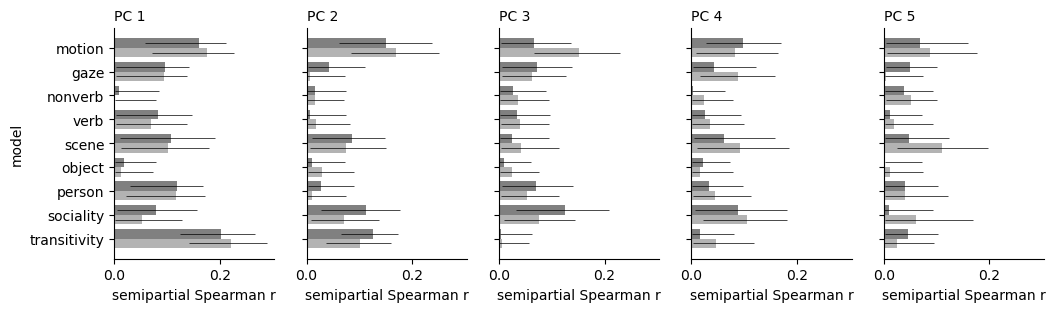

In [21]:
# Visualize correlations between PC RDMs and models
fig, axs = plt.subplots(1, 5, figsize=(12, 3), sharex=True, sharey=True)
for ax, pc_id in zip(axs, np.arange(1, 6)): 
    sns.barplot(x='semipartial Spearman r', y='model', hue='hemisphere',
                data=pc_semis.loc[pc_semis['PC'] == pc_id],
                palette=['.5', '.7'], ax=ax, legend=False)
    ax.annotate(f'PC {pc_id}', xy=(0, 1.02), xycoords='axes fraction',
                ha='left', va='bottom')
    cis = np.stack(((pc_semis['semipartial Spearman r'][pc_semis['PC'] == pc_id].values) - 
                     pc_boot['lower'][pc_boot['PC'] == pc_id].values,
                    (pc_boot['upper'][pc_boot['PC'] == pc_id].values -
                     pc_semis['semipartial Spearman r'][pc_semis['PC'] == pc_id].values)))
    ci_y = [p.get_y() + 0.5 * p.get_height() for p in ax.patches]
    ci_x = [p.get_width() for p in ax.patches]
    ax.errorbar(x=ci_x, y=ci_y, xerr=cis, fmt='none', c='k', lw=.5)
    sns.despine()

In [18]:
# # Compute PCA loadings and map onto brain(???)
# pc_id = 0
# n_vertices = 40962

# loading_maps = {}
# for hemi in hemis:
#     loading_map = np.zeros((1, n_vertices))
#     loading_map[0, np.where(vt_masks[hemi])[1]] = vt_loadings[hemi][:, pc_id]
#     #loading_map[0, np.where(vt_masks[hemi])[1]] = vt_loadings[hemi][pc_id]
#     loading_maps[hemi] = loading_map

# for hemi in hemis:
#     f = f'vt_loadings_pc-{pc_id + 1}_hemi-{hemi}.gii'
#     template_f = data_dir + f'/{hemi}_mask_VT-v2.gii'
#     write_gifti(loading_maps[hemi].astype('float32'), f, template_f)

In [24]:
# (Re)load in VT RDMs and average across subjects
hemis = ['lh', 'rh']
vt_maps = np.load('vt_searchlights.npy', allow_pickle=True).item()
vt_avg = {'lh': [], 'rh': []}
for hemi in hemis:
    vt_avg[hemi] = np.mean([v for v in vt_maps[hemi].values()], axis=0) 

In [25]:
# Run PCA to reduce RDM dimensionality
vt_pca_T, vt_vaf_T = {}, {}
for hemi in hemis:
    pca = PCA()
    #vt_pca_T[hemi] = pca.fit_transform(vt_avg[hemi].T)
    vt_pca_T[hemi] = pca.fit_transform(zscore(vt_avg[hemi], axis=0).T)
    vt_vaf_T[hemi] = pca.explained_variance_ratio_

vaf_thresh = .95
n_pcs = {}
for hemi in hemis:
    n_pcs[hemi] = np.sum(np.cumsum(vt_vaf_T[hemi]) < vaf_thresh) + 1
    print(f"{n_pcs[hemi]} PCs required to explain {vaf_thresh} variance in {hemi} VT RDMs")

30 PCs required to explain 0.95 variance in lh VT RDMs
32 PCs required to explain 0.95 variance in rh VT RDMs


In [26]:
# Test out k-means clustering with silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

hemi = 'lh'
k = 30
pca = PCA(n_components=k)
vt_pca30 = pca.fit_transform(zscore(vt_avg[hemi], axis=0).T)

vt_in = vt_pca30

labels, scores, silhouettes, inertias = [], [], [], []
ks = np.arange(2, 11)
for k in ks:
    kmeans = KMeans(n_clusters=k, init='random', n_init=100, random_state=42)
    cluster_labels = kmeans.fit_predict(vt_in)
    labels.append(cluster_labels)
    scores.append(silhouette_score(vt_in, cluster_labels).item())
    silhouettes.append(silhouette_samples(vt_in, cluster_labels))
    inertias.append(kmeans.inertia_)

print('\n'.join([f'silhouette score for {k} clusters: {score:.6f}' for k, score in zip(ks, scores)]))

silhouette score for 2 clusters: 0.242361
silhouette score for 3 clusters: 0.287969
silhouette score for 4 clusters: 0.290563
silhouette score for 5 clusters: 0.264895
silhouette score for 6 clusters: 0.280359
silhouette score for 7 clusters: 0.293772
silhouette score for 8 clusters: 0.297935
silhouette score for 9 clusters: 0.290992
silhouette score for 10 clusters: 0.302795


In [27]:
# Recompute PCA
cluster_labels, centroid_rdms = {}, {}

for hemi in hemis:
    pca_k = 30
    pca = PCA(n_components=pca_k)
    vt_in = pca.fit_transform(zscore(vt_avg[hemi], axis=0).T)
    print(f"{hemi} VT shape: {vt_avg[hemi].T.shape}")
    print(f"{hemi} PCA VT shape: {vt_in.shape}")

    # Compute k-means with k = 4 and save labels
    k = 4
    kmeans = KMeans(n_clusters=k, init='random', n_init=100, random_state=42)
    cluster_labels[hemi] = kmeans.fit_predict(vt_in)
    print(f"{hemi} silhouette: {silhouette_score(vt_in, cluster_labels[hemi])}")

    # Extract centroids from RDM
    centroids_pca = kmeans.cluster_centers_
    centroid_rdms[hemi] = pca.inverse_transform(centroids_pca)
    print(f"{hemi} centroid shape: {centroid_rdms[hemi].shape}")
    
    n_vertices = 40962
    cluster_map = np.zeros((1, n_vertices))
    cluster_map[0, np.where(vt_masks[hemi])[1]] = cluster_labels[hemi] + 1
    f = f'vt_kmeans-{k}_hemi-{hemi}.gii'
    template_f = data_dir + f'/{hemi}_mask_VT-v2.gii'
    write_gifti(cluster_map.astype('float32'), f, template_f)

lh VT shape: (1851, 4005)
lh PCA VT shape: (1851, 30)
lh silhouette: 0.29056259112579774
lh centroid shape: (4, 4005)
rh VT shape: (1785, 4005)
rh PCA VT shape: (1785, 30)
rh silhouette: 0.3116148095427844
rh centroid shape: (4, 4005)


In [28]:
# Directly average searchlight RDMs according to cluster labels
cluster_means = {}
for hemi in hemis:
    cluster_means[hemi] = []
    for cluster_id in np.arange(4):
        cluster_means[hemi].append(
            np.mean(vt_avg[hemi][:, cluster_labels[hemi] == cluster_id], axis=1))

        # Confirm they closely match inverse PCA k-means centroids
        print(f"Correlation between centroid and mean: "
              f"{spearmanr(cluster_means[hemi][cluster_id],
                           centroid_rdms[hemi][cluster_id])[0]:.6f}")
    cluster_means[hemi] = np.stack(cluster_means[hemi])

Correlation between centroid and mean: 0.996221
Correlation between centroid and mean: 0.991420
Correlation between centroid and mean: 0.997308
Correlation between centroid and mean: 0.999561
Correlation between centroid and mean: 0.994407
Correlation between centroid and mean: 0.996733
Correlation between centroid and mean: 0.998047
Correlation between centroid and mean: 0.999483


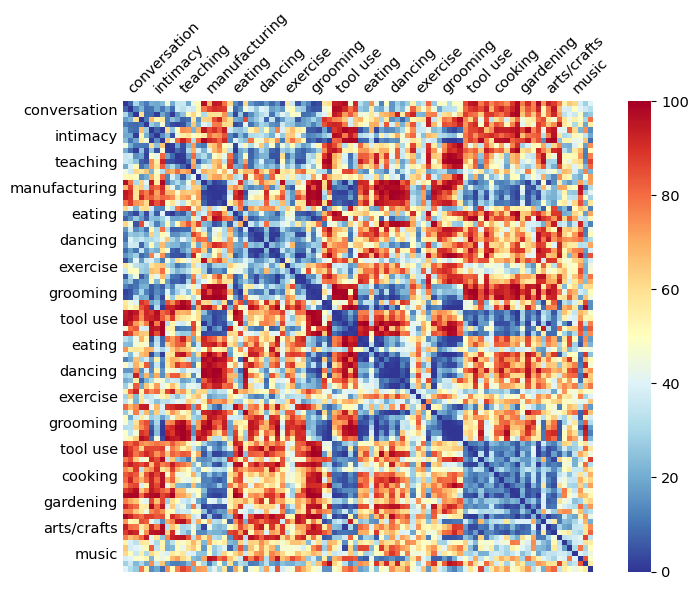

In [29]:
# Visualize example centroid RDM
hemi = 'rh'
cluster_id = 3
cluster_numbers = {0: 3, 1: 1, 2: 4, 3: 2}
plot_rdm(cluster_means[hemi][cluster_id], reorder=reorder, labels=sparse_ordered_labels,
         save_f=f'vt_kmeans_k-4_cluster-{cluster_id + 1}_{hemi}_rdm.png')
np.save(f'vt_kmeans_k-4_cluster-{cluster_numbers[cluster_id]}_hemi-{hemi}_rdm.npy',
        cluster_means[hemi][cluster_id])

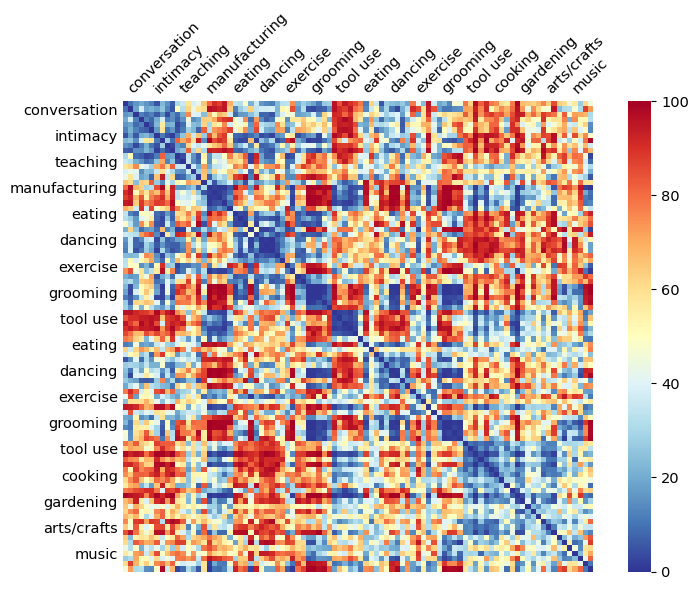

In [30]:
# Visualize example centroid RDM
hemi = 'lh'
centroid_id = 0
plot_rdm(centroid_rdms[hemi][centroid_id], reorder=reorder, labels=sparse_ordered_labels)

In [31]:
# Compile correlations with model RDMs
cluster_corr = {'Spearman r': [], 'model': [], 'cluster': [], 'hemisphere': []}
for cluster_id in np.arange(4):
    for hemi in hemis:
        for model_name in model_names:
            # Absolute r because PCs have arbitrary polarity
            r = spearmanr(centroid_rdms[hemi][cluster_id], model_rdms[model_name])[0]
            cluster_corr['Spearman r'].append(r)
            cluster_corr['model'].append(model_name)
            cluster_corr['cluster'].append(cluster_id + 1)
            cluster_corr['hemisphere'].append(hemi)

cluster_corr = pd.DataFrame(cluster_corr)

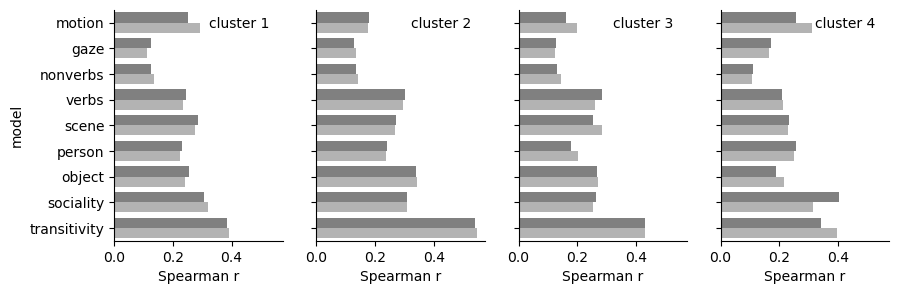

In [32]:
fig, axs = plt.subplots(1, 4, figsize=(10, 3), sharex=True, sharey=True)
for ax, cluster_id in zip(axs, np.arange(1, 5)): 
    sns.barplot(x='Spearman r', y='model', hue='hemisphere',
                data=cluster_corr.loc[cluster_corr['cluster'] == cluster_id],
                palette=['.5', '.7'], ax=ax, legend=False)
    ax.annotate(f'cluster {cluster_id}', xy=(.92, .97), xycoords='axes fraction',
                ha='right', va='top')
    sns.despine()

In [33]:
# Compile semi-partial correlations with model RDMs
cluster_semis = {'semipartial Spearman r': [], 'model': [], 'cluster': [], 'hemisphere': []}
for cluster_id in np.arange(4):
    for hemi in hemis:
        for model_name in model_names:

            centroid_df = pd.DataFrame(
                {'neural': cluster_means[hemi][cluster_id],
                 **model_rdms})
            r = pg.partial_corr(
                data=centroid_df, x='neural', y=model_name,
                x_covar=[m for m in model_rdms.keys()
                         if m is not model_name],
                method='spearman').r.values[0]
            
            # Absolute r because PCs have arbitrary polarity
            cluster_semis['semipartial Spearman r'].append(r)
            cluster_semis['model'].append(model_name)
            cluster_semis['cluster'].append(cluster_id + 1)
            cluster_semis['hemisphere'].append(hemi)

cluster_semis = pd.DataFrame(cluster_semis)
cluster_semis.to_csv('kmeans_k-4_semipartial.csv', index=False)

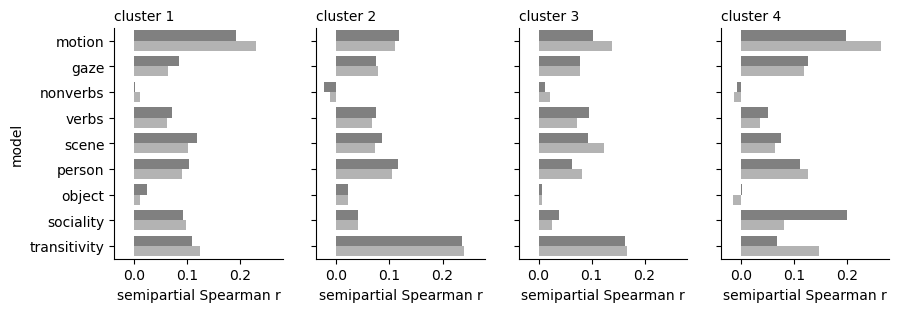

In [34]:
fig, axs = plt.subplots(1, 4, figsize=(10, 3), sharex=True, sharey=True)
for ax, cluster_id in zip(axs, np.arange(1, 5)): 
    sns.barplot(x='semipartial Spearman r', y='model', hue='hemisphere',
                data=cluster_semis.loc[cluster_semis['cluster'] == cluster_id],
                palette=['.5', '.7'], ax=ax, legend=False)
    ax.annotate(f'cluster {cluster_id}', xy=(0, 1.02), xycoords='axes fraction',
                ha='left', va='bottom')
    sns.despine()

In [ ]:
# Bootstrap subjects for semi-partial correlations with model RDMs
if not exists('kmeans_k-4_semipartial_boot.csv'):
    vt_maps = np.load('vt_searchlights.npy', allow_pickle=True).item()
    vt_maps['lh'] = np.stack(list(vt_maps['lh'].values()))
    vt_maps['rh'] = np.stack(list(vt_maps['rh'].values()))
    
    n_subjs = 23
    n_boots = 1000
    cluster_boot = {'upper': [], 'lower': [], 'model': [], 'cluster': [], 'hemisphere': []}
    for cluster_id in np.arange(4):
        for hemi in hemis:
    
            for model_name in model_names:
                r_boots = []
                for b in np.arange(n_boots):
                    boot_ids = np.random.choice(np.arange(n_subjs), n_subjs, replace=True)
                    vt_boot = np.mean(vt_maps[hemi][boot_ids], axis=0)
                    vt_boot = np.mean(vt_boot[:, cluster_labels[hemi] == cluster_id],
                        axis=1)
    
                    centroid_df = pd.DataFrame(
                        {'neural': vt_boot,
                         **model_rdms})
                    r_boots.append(pg.partial_corr(
                        data=centroid_df, x='neural', y=model_name,
                        x_covar=[m for m in model_rdms.keys()
                                 if m is not model_name],
                        method='spearman').r.values[0])
                
                # Absolute r because PCs have arbitrary polarity
                cluster_boot['upper'].append(np.percentile(r_boots, 97.5))
                cluster_boot['lower'].append(np.percentile(r_boots, 2.5))
                cluster_boot['model'].append(model_name)
                cluster_boot['cluster'].append(cluster_id + 1)
                cluster_boot['hemisphere'].append(hemi)
            print(f"Finished bootstrap correlations for PC {pc_id} {hemi}")
    
    cluster_boot = pd.DataFrame(cluster_boot)

In [67]:
if not exists('kmeans_k-4_semipartial_boot.csv'):
    cluster_boot.to_csv('kmeans_k-4_semipartial_boot.csv', index=False)
cluster_boot = pd.read_csv('kmeans_k-4_semipartial_boot.csv')

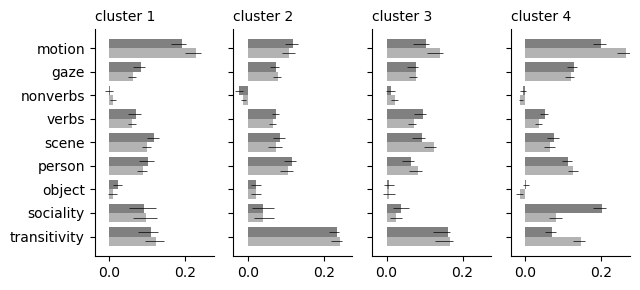

In [68]:
fig, axs = plt.subplots(1, 4, figsize=(6.5, 3), sharex=True, sharey=True)
for ax, cluster_id in zip(axs, np.arange(1, 5)): 
    sns.barplot(x='semipartial Spearman r', y='model', hue='hemisphere',
                data=cluster_semis.loc[cluster_semis['cluster'] == cluster_id],
                palette=['.5', '.7'], ax=ax, legend=False)
    ax.set(xlim=(-.0375, .275), ylabel=None, xlabel=None)
    ax.annotate(f'cluster {cluster_id}', xy=(0, 1.02), xycoords='axes fraction',
                ha='left', va='bottom')
    cis = np.stack((
        (cluster_semis['semipartial Spearman r'][cluster_semis['cluster'] == cluster_id].values) - 
         cluster_boot['lower'][cluster_boot['cluster'] == cluster_id].values,
        (cluster_boot['upper'][cluster_boot['cluster'] == cluster_id].values -
         cluster_semis['semipartial Spearman r'][cluster_semis['cluster'] == cluster_id].values)))
    ci_y = [p.get_y() + 0.5 * p.get_height() for p in ax.patches]
    ci_x = [p.get_width() for p in ax.patches]
    ax.errorbar(x=ci_x, y=ci_y, xerr=cis, fmt='none', c='k', lw=.5)
    sns.despine()
    plt.tight_layout()

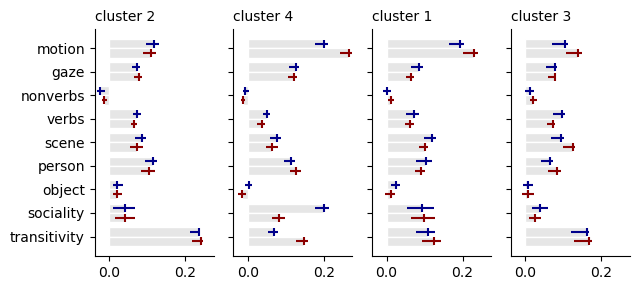

In [69]:
plt.rcParams['svg.fonttype'] = 'none'
fig, axs = plt.subplots(1, 4, figsize=(6.5, 3), sharex=True, sharey=True)
for ax, cluster_id in zip(axs, [2, 4, 1, 3]): 
    sns.barplot(x='semipartial Spearman r', y='model', hue='hemisphere',
                data=cluster_semis.loc[cluster_semis['cluster'] == cluster_id],
                palette=['.9', '.9'], ax=ax, legend=False, edgecolor='w')
    sns.pointplot(x='semipartial Spearman r', y='model', hue='hemisphere',
                  data=cluster_semis.loc[cluster_semis['cluster'] == cluster_id],
                  palette=['darkblue', 'darkred'], ax=ax, legend=False,
                  linestyle='none', markersize=6, dodge=.4,
                  markers='|', markeredgewidth=1.5)
    ax.set(xlim=(-.038, .275), ylabel=None, xlabel=None)
    ax.annotate(f'cluster {cluster_id}', xy=(0, 1.02), xycoords='axes fraction',
                ha='left', va='bottom')
    cis = np.stack((
        (cluster_semis['semipartial Spearman r'][cluster_semis['cluster'] == cluster_id].values) - 
         cluster_boot['lower'][cluster_boot['cluster'] == cluster_id].values,
        (cluster_boot['upper'][cluster_boot['cluster'] == cluster_id].values -
         cluster_semis['semipartial Spearman r'][cluster_semis['cluster'] == cluster_id].values)))
    ci_y = [p.get_y() + 0.5 * p.get_height() for p in ax.patches]
    ci_x = [p.get_width() for p in ax.patches]
    cs = ['darkblue'] * 9 + ['darkred'] * 9
    for i in np.arange(len(ci_x)):
        ax.errorbar(x=ci_x[i], y=ci_y[i], xerr=cis[:, i, np.newaxis],
                    fmt='none', c=cs[i], lw=1.5)
    sns.despine()
    plt.tight_layout()
    plt.savefig('vt_kmeans_k-4_bars.svg', dpi=300,
                transparent=True, bbox_inches='tight');

For n_clusters = 2 The average silhouette_score is : 0.24450566285662462
For n_clusters = 3 The average silhouette_score is : 0.2894236490788017
For n_clusters = 4 The average silhouette_score is : 0.31161481298498594
For n_clusters = 5 The average silhouette_score is : 0.259906239882363
For n_clusters = 6 The average silhouette_score is : 0.27291054073537113
For n_clusters = 7 The average silhouette_score is : 0.294154862277839
For n_clusters = 8 The average silhouette_score is : 0.3055662472408421
For n_clusters = 9 The average silhouette_score is : 0.3062033231317069
For n_clusters = 10 The average silhouette_score is : 0.31865911100470146


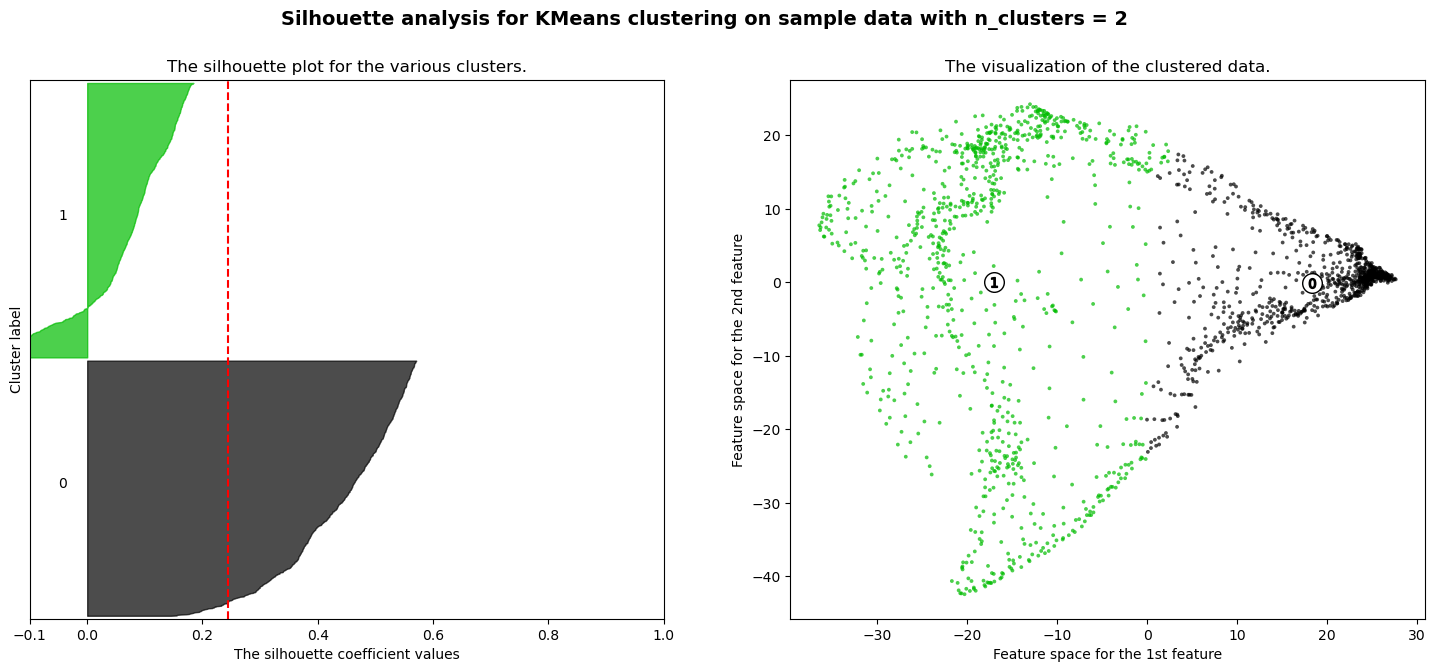

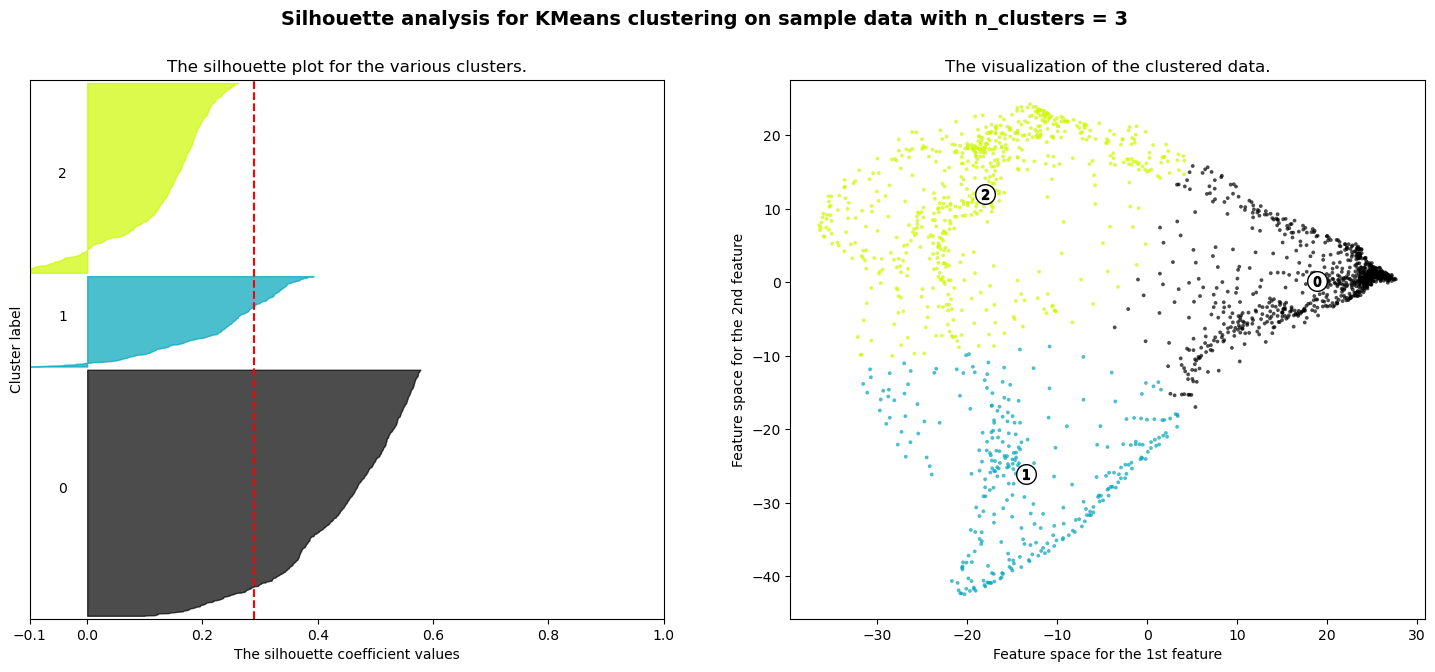

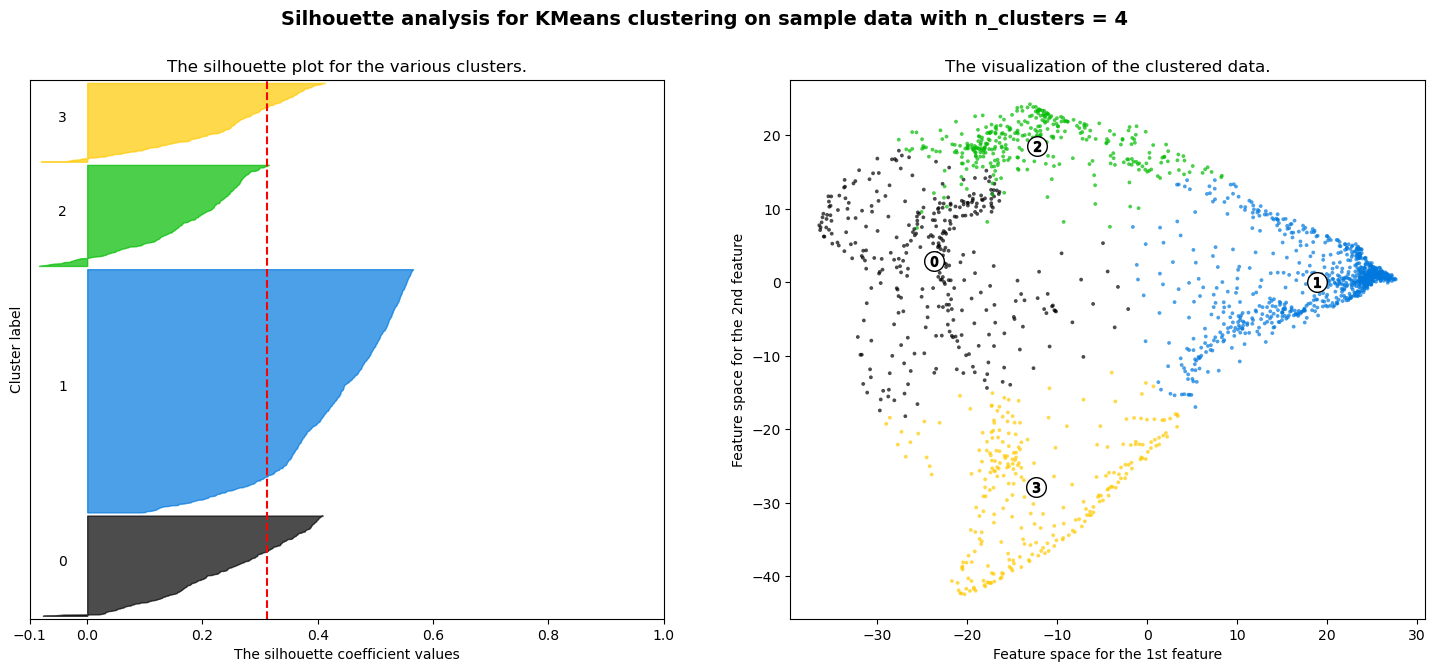

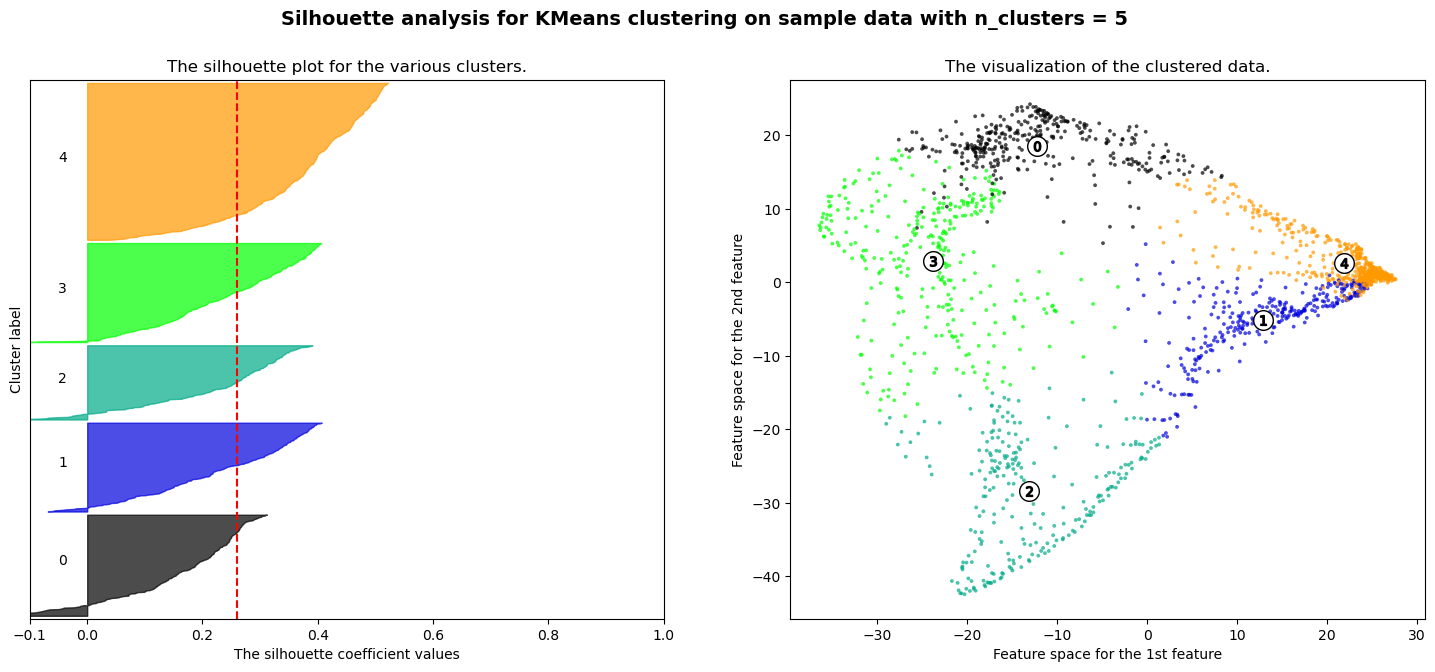

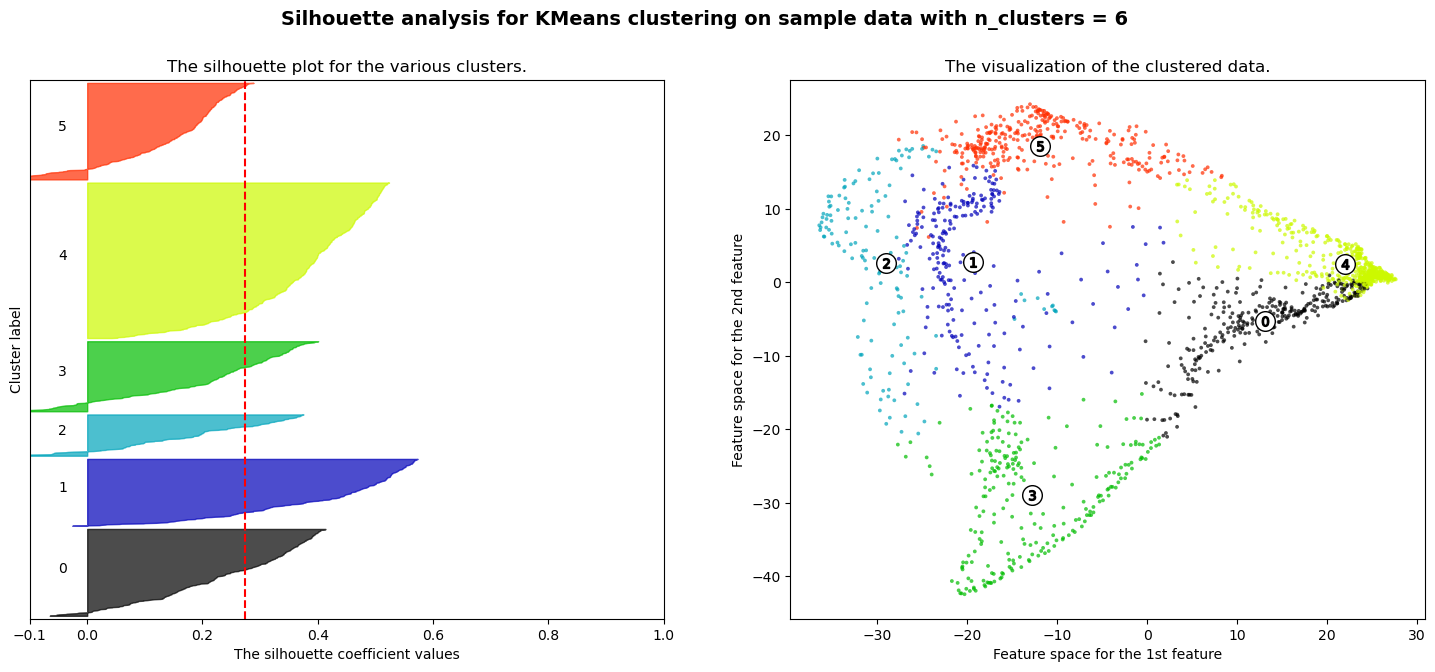

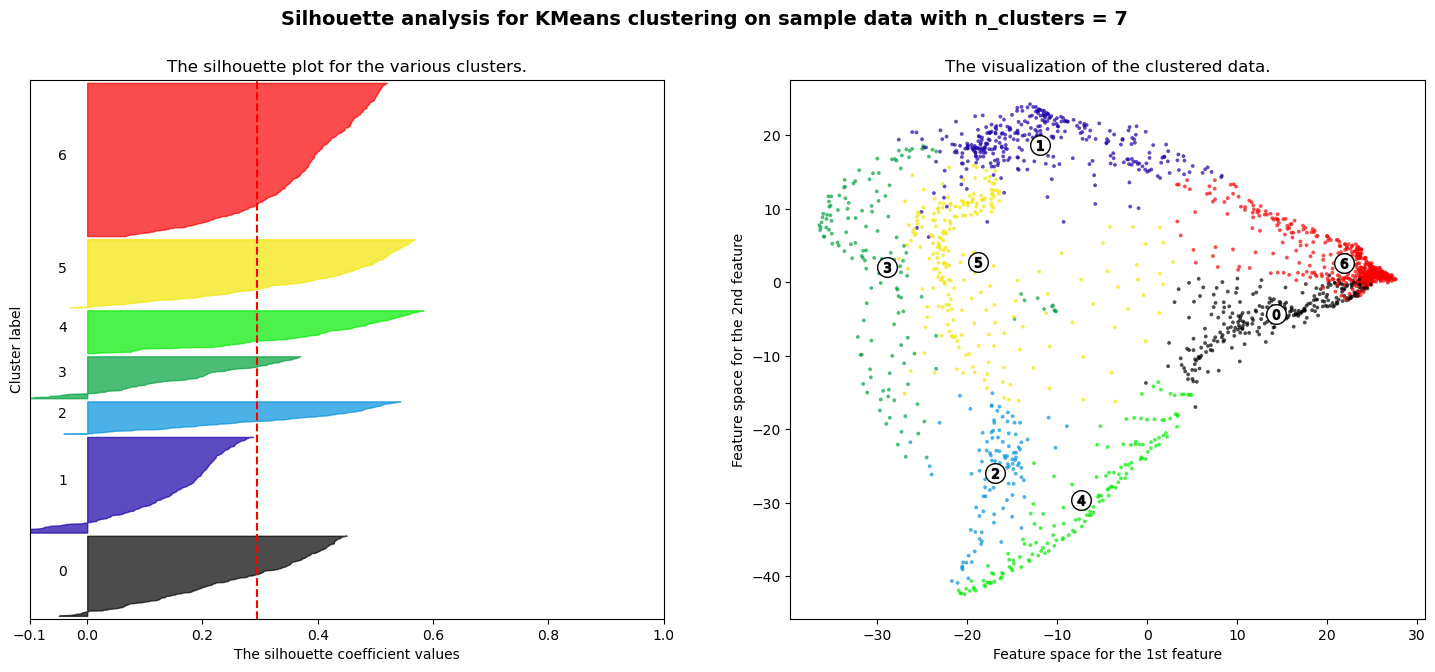

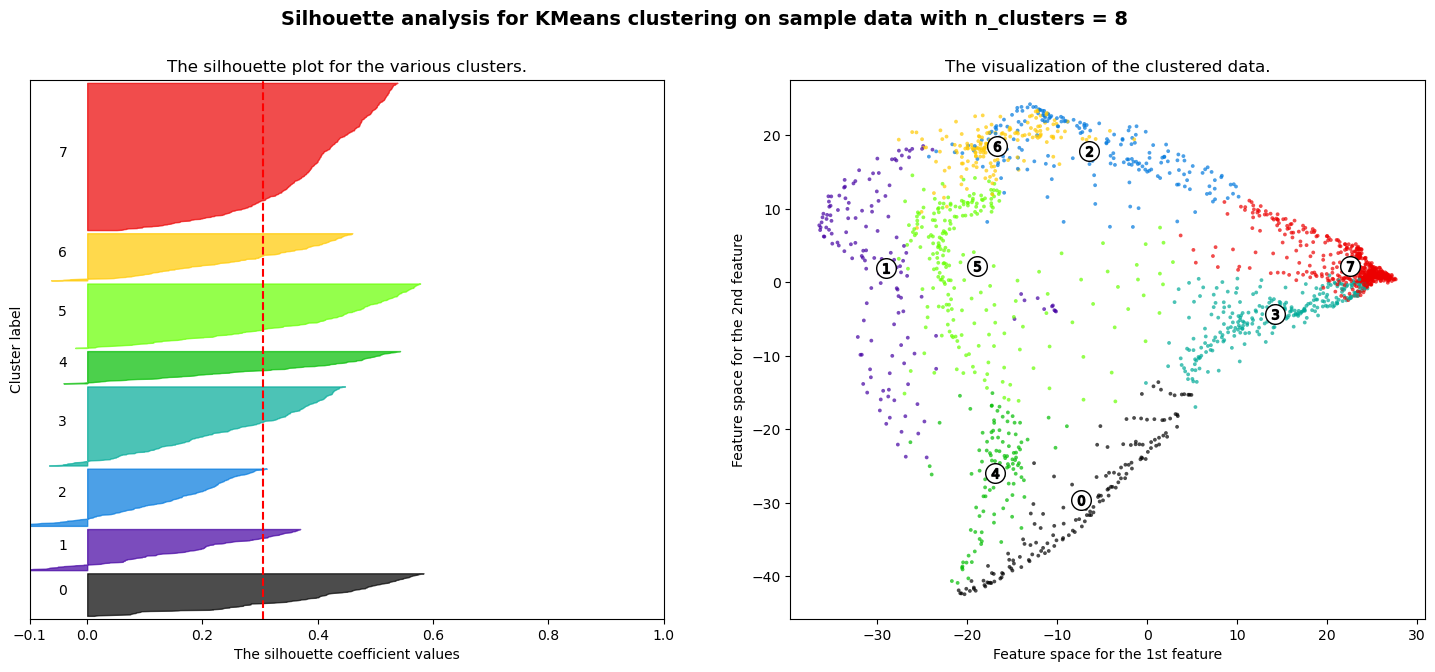

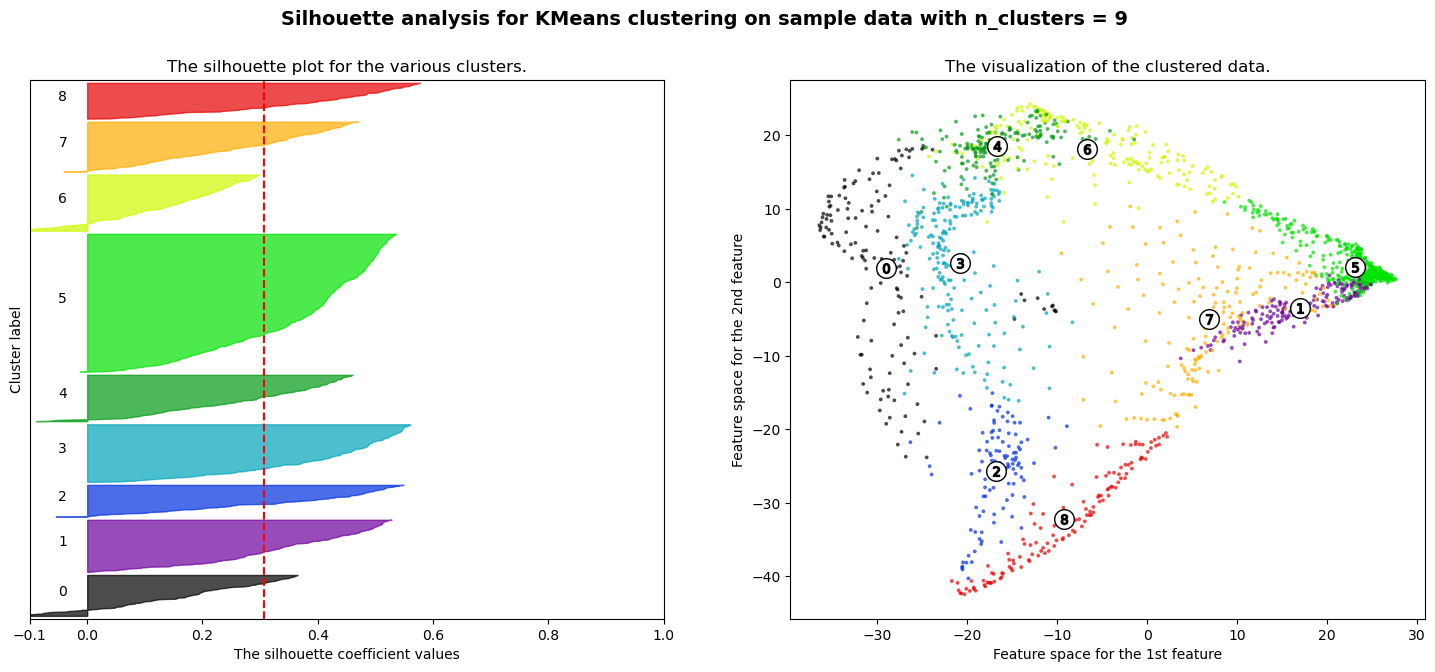

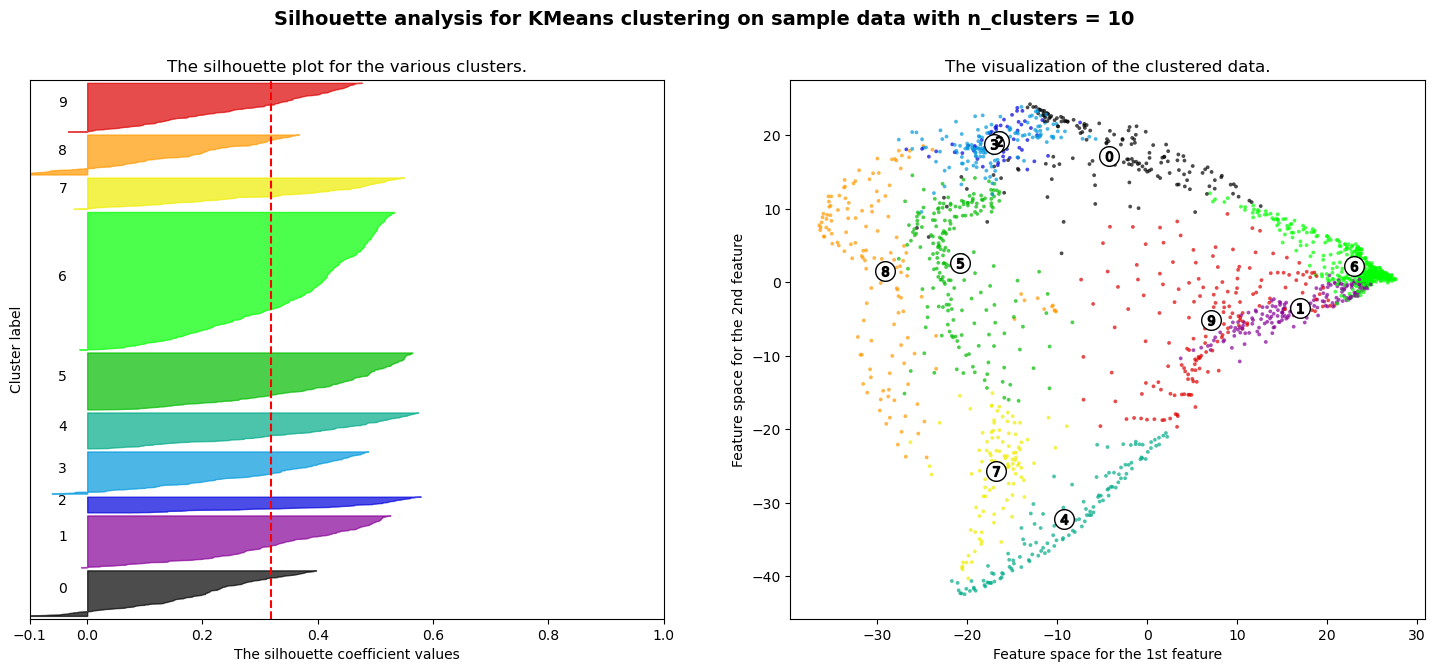

In [30]:
# Sklearn visualization of silhouette scores
import matplotlib.cm as cm
X = vt_in

for n_clusters in ks:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, init='random', n_init=100, random_state=42)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

silhouette score for 4 clusters: 0.311613


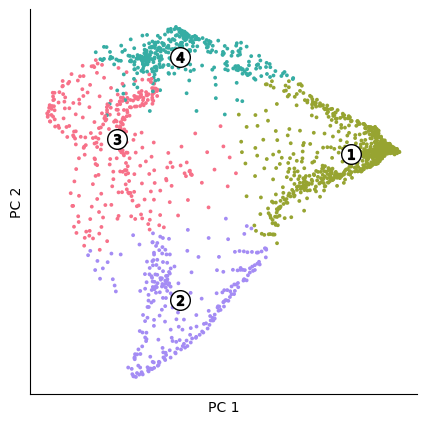

In [184]:
# Sklearn visualization of silhouette scores
import matplotlib.cm as cm

hemi = 'rh'
pca_k = 30
pca = PCA(n_components=pca_k)
vt_in = pca.fit_transform(zscore(vt_avg[hemi], axis=0).T)
X = vt_in

n_clusters = 4

clusterer = KMeans(n_clusters=n_clusters, init='random', n_init=100, random_state=42)
cluster_labels = clusterer.fit_predict(X)
silhouette_avg = silhouette_score(X, cluster_labels)
print(f'silhouette score for {n_clusters} clusters: {silhouette_avg:.6f}')

fig, ax = plt.subplots(figsize=(5, 5))

colors = [sns.husl_palette(n_clusters)[c] for c in cluster_labels]
ax.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0,
           alpha=1, c=colors)

# Labeling the clusters
centers = clusterer.cluster_centers_
# Draw white circles at cluster centers
ax.scatter(centers[:, 0], centers[:, 1], marker='o', c='w',
           alpha=1, s=200, edgecolor='k')

cluster_numbers = [3, 1, 4, 2]
for i, (c, n) in enumerate(zip(centers, cluster_numbers)):
    ax.scatter(c[0], c[1], marker=f'${n}$', alpha=1, s=50, edgecolor='k')

ax.set(xticks=[], yticks=[], xlabel='PC 1', ylabel='PC 2');
sns.despine()
plt.savefig(f'vt_kmeans_k-4_scatter_{hemi}.svg', dpi=300,
            transparent=True, bbox_inches='tight');